Imports & Drive Mount

In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPU Ready")

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score,
    precision_recall_curve,
    average_precision_score
)

from sklearn.utils.class_weight import compute_class_weight

TensorFlow: 2.20.0
Available GPUs: []
GPU Ready


Dataset Path & Params

In [2]:
train_dir = r'E:\ML\BDWaste_split\train'
val_dir   = r'E:\ML\BDWaste_split\validation'
test_dir  = r'E:\ML\BDWaste_split\test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

Data Generator

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 1830 images belonging to 2 classes.
Found 394 images belonging to 2 classes.
Found 401 images belonging to 2 classes.
Class indices: {'Digestive': 0, 'Indigestive': 1}


Class Weights (from TRAIN split)

In [4]:
classes = np.unique(train_gen.classes)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_gen.classes
)
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

Class weights: {0: 0.9491701244813278, 1: 1.056581986143187}


Model: MobileNetV3-Large + Custom Head

In [5]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,297 (9.89 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Stage-1 Training (Head Only)

In [6]:
checkpoint_stage1 = tf.keras.callbacks.ModelCheckpoint(
    'best_stage1.weights.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    save_weights_only=True
)

history_1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint_stage1]
)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 370s 6s/step - accuracy: 0.9475 - auc: 0.9880 - loss: 0.1408 - val_accuracy: 0.9924 - val_auc: 0.9998 - val_loss: 0.0351
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 363s 6s/step - accuracy: 0.9863 - auc: 0.9990 - loss: 0.0373 - val_accuracy: 0.9898 - val_auc: 1.0000 - val_loss: 0.0250
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 358s 6s/step - accuracy: 0.9907 - auc: 0.9994 - loss: 0.0275 - val_accuracy: 0.9975 - val_auc: 1.0000 - val_loss: 0.0092
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 359s 6s/step - accuracy: 0.9962 - auc: 0.9993 - loss: 0.0157 - val_accuracy: 0.9975 - val_auc: 1.0000 - val_loss: 0.0064
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 375s 6s/step - accuracy: 0.9956 - auc: 0.9993 - loss: 0.0159 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0047
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 352s 6s/step - accuracy: 0.9934 - auc: 0.9998 - loss: 0.0150 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0022
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 351s 6s/

Stage-2 Fine-tuning (Safe)

In [7]:
base_model.trainable = True

# Freeze BatchNorm layers for stability
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Unfreeze only the last N layers (you can tune N=20/30)
N = 20
for layer in base_model.layers[:-N]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]

history_2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 341s 6s/step - accuracy: 0.9962 - auc: 0.9999 - loss: 0.0127 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 5.9470e-04
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 317s 5s/step - accuracy: 0.9962 - auc: 0.9994 - loss: 0.0113 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 4.7136e-04
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 314s 5s/step - accuracy: 0.9956 - auc: 1.0000 - loss: 0.0080 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 4.3012e-04
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 309s 5s/step - accuracy: 0.9984 - auc: 1.0000 - loss: 0.0043 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 4.3669e-04
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 308s 5s/step - accuracy: 0.9989 - auc: 1.0000 - loss: 0.0042 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 5.0165e-04
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 312s 5s/step - accuracy: 0.9989 - auc: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0021


Plot Training Curves (Loss, Accuracy, AUC)

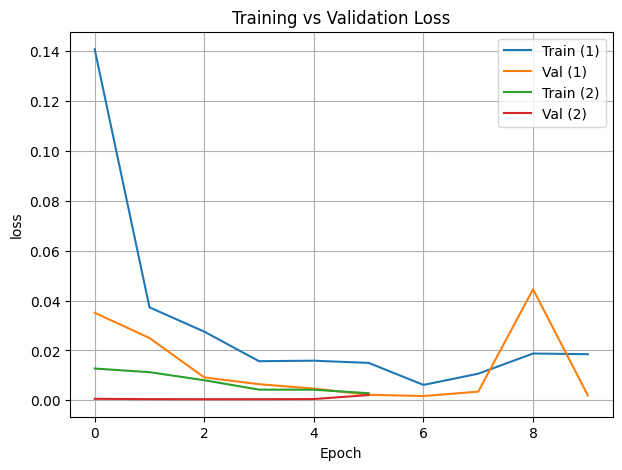

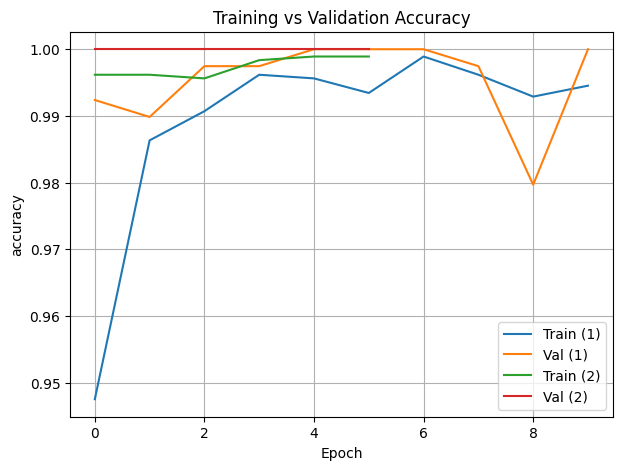

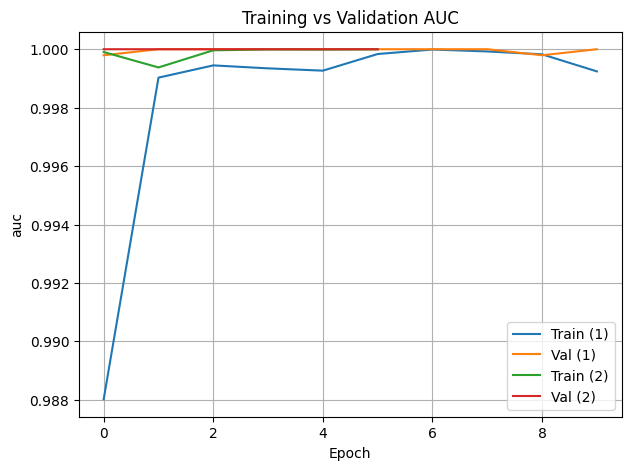

In [8]:
def plot_history(histories, metric, title):
    plt.figure(figsize=(7,5))
    for i, h in enumerate(histories, start=1):
        if metric in h.history and f"val_{metric}" in h.history:
            plt.plot(h.history[metric], label=f"Train ({i})")
            plt.plot(h.history[f"val_{metric}"], label=f"Val ({i})")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history([history_1, history_2], "loss", "Training vs Validation Loss")
plot_history([history_1, history_2], "accuracy", "Training vs Validation Accuracy")
plot_history([history_1, history_2], "auc", "Training vs Validation AUC")

Evaluation + Metrics

In [9]:
y_true = test_gen.classes
y_prob = model.predict(test_gen).flatten()
y_pred = (y_prob > 0.5).astype(int)

loss, acc, auc_tf = model.evaluate(test_gen)

print("Test Accuracy:", acc)
print(f"\nOverall Accuracy: {acc:.4f}")
print(f"TensorFlow AUC:   {auc_tf:.4f}")

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_gen.class_indices.keys())
))

balanced_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.4f}")

auc = roc_auc_score(y_true, y_prob)
print(f"AUC-ROC Score:     {auc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 61s 5s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.9950 - auc: 0.9999 - loss: 0.0109
Test Accuracy: 0.9950124621391296

Overall Accuracy: 0.9950
TensorFlow AUC:   0.9999

Confusion Matrix:
 [[210   2]
 [  0 189]]

Classification Report:
              precision    recall  f1-score   support

   Digestive       1.00      0.99      1.00       212
 Indigestive       0.99      1.00      0.99       189

    accuracy                           1.00       401
   macro avg       0.99      1.00      0.99       401
weighted avg       1.00      1.00      1.00       401

Balanced Accuracy: 0.9953
AUC-ROC Score:     0.9999


Confusion Matrix Plot (Heatmap)

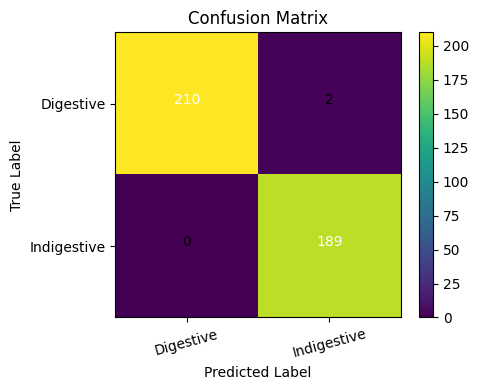

In [10]:
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
class_names = list(val_gen.class_indices.keys())
plt.xticks(tick_marks, class_names, rotation=15)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

ROC Curve Plot

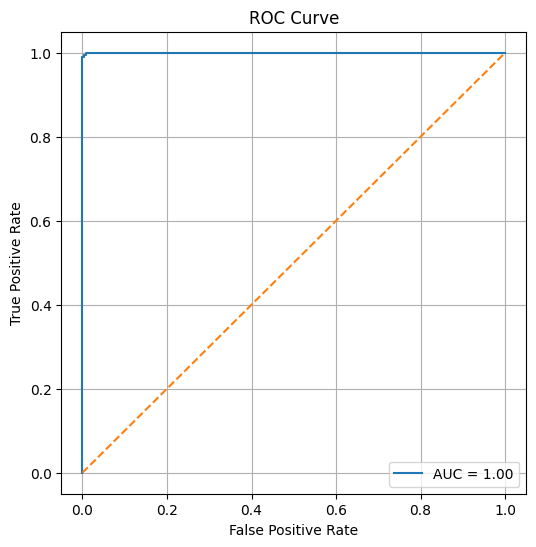

In [11]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

Precision-Recall Curve

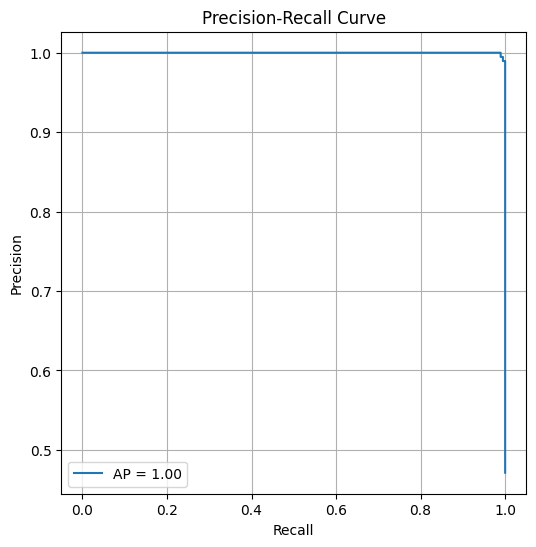

In [12]:
prec, rec, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

plt.figure(figsize=(6,6))
plt.plot(rec, prec, label=f"AP = {ap:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()